# TreeFlow likelihood/ratio-transform benchmarks

This notebook is the inlined, BEAST-free replacement for the
[`treeflow-benchmarks`](https://github.com/christiaanjs/treeflow-benchmarks)
Snakemake pipeline that produced the benchmark figure (Fig 7) in the TreeFlow
paper. Differences from that pipeline:

* **No BEAST 2 / Feast dependency.** Coalescent tree topologies and DNA
  sequence alignments are simulated entirely with treeflow
  (`experiments/benchmarks/simulate.py`) instead of shelling out to `beast`.
  `ConstantCoalescent`'s `_sample_n` is a placeholder ("Dummy sampling") in
  treeflow today, so `simulate_coalescent_tree` implements the standard
  forwards-in-time coalescent waiting-time algorithm directly; sequences are
  simulated by calling `treeflow.model.phylo_model.get_sequence_distribution`
  (the same function that builds production likelihoods) and sampling from it.
* **A Jupyter notebook instead of Snakemake + R.** All simulation,
  benchmarking, data aggregation and plotting happens here. Log-log scaling
  fits use `numpy.polyfit` instead of R's `lm`.
* **A native-ops comparison.** `treeflow_native` reuses the exact same
  `TreeflowLikelihoodBenchmarkable`/`TreeflowRatioTransformBenchmarkable`
  classes as `treeflow`, just with `use_native=True` -- both `LeafCTMC` and
  `NodeHeightRatioBijector` already support routing through treeflow's
  compiled C++ ops (`treeflow.acceleration.native`), so this is a one-line
  toggle rather than a new implementation.
* **JAX (via [phylojax](https://github.com/christiaanjs/phylojax)) runs if
  installed**, and BEAGLE/[bito](https://github.com/phylovi/bito) runs if
  installed -- both are optional and the sweep skips them gracefully
  otherwise. bito is benchmarked two ways: `beagle_bito` through the
  TreeFlow `tf.function` wrapper (same overhead footing as the `treeflow`
  methods) and `beagle_bito_direct` driving the bito instance directly
  (no TensorFlow wrapper), isolating BEAGLE's raw compute.

Supporting code lives in `experiments/benchmarks/`:

| module | contents |
| --- | --- |
| `simulate.py` | coalescent tree + sequence simulation, FASTA/newick writers |
| `params.py` | parameter-dict plumbing shared by the benchmarkables |
| `benchmarking.py` | generic timing harness (`LikelihoodBenchmarkable`, `RatioTransformBenchmarkable`) |
| `benchmarkables.py` | treeflow / treeflow-native / jax / beagle-bito implementations |
| `runner.py` | simulate -> benchmark sweep -> long-format `pandas.DataFrame` |


In [1]:
import sys
from pathlib import Path

# Make `experiments/benchmarks` importable as the `benchmarks` package,
# regardless of the notebook's working directory.
_experiments_dir = Path.cwd()
if not (_experiments_dir / "benchmarks").exists():
    _experiments_dir = Path.cwd() / "experiments"
sys.path.insert(0, str(_experiments_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from benchmarks.benchmarkables import bito_available, phylojax_available
from benchmarks.runner import (
    MANUSCRIPT_METHODS,
    fit_log_log_lines,
    run_likelihood_sweep,
    run_ratio_transform_sweep,
    write_benchmark_config,
    write_manuscript_data,
)

print("phylojax available:", phylojax_available())
print("bito/BEAGLE available:", bito_available())

/Users/christiaanswanepoel/.pyenv/versions/treeflow/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Silencing TensorFlow...


phylojax available: True
bito/BEAGLE available: True


## Configuration

Two profiles select the sweep size, chosen by the `BENCHMARK_PROFILE` environment variable (default `quick`):

* **`quick`** -- `taxon_counts = [8, 16, 32, 64, 128]`, 3 replicates, 200 sites, 10 repeats. Exercises every method end to end in a couple of minutes; this is what runs from a browser session with nothing set.
* **`full`** -- the manuscript sweep: `taxon_counts = [32, 64, 128, 256, 512, 1024, 2048]`, 10 replicates, 1000 sites, 100 repeats, with eager JAX capped at 512 taxa. Takes hours and needs BEAGLE/bito + JAX installed for every series.

Select the full sweep either by setting the env var (`BENCHMARK_PROFILE=full`) before launching the kernel, or -- when running headless -- with `python run_benchmark.py --profile full`, which sets it for you and streams progress to the terminal. Everything else in the notebook is identical across profiles.

In [2]:
import os

# Two parameter profiles select the sweep size. "quick" (the default -- and what
# runs from a browser session with no environment set) exercises every method
# end to end in a couple of minutes; "full" reproduces the manuscript sweep
# (hours; needs bito + jax installed for every series). Choose with the
# BENCHMARK_PROFILE environment variable, e.g. `run_benchmark.py --profile full`.
PROFILE = os.environ.get("BENCHMARK_PROFILE", "quick")

PROFILES = {
    "ci": dict(taxon_counts=[8, 16], replicates=1, sequence_length=100, repeats=3, method_max_taxon_count={"jax": 512}),  # tiny smoke-test sweep (CI)
    "quick": dict(
        taxon_counts=[8, 16, 32, 64, 128],
        replicates=3,
        sequence_length=200,
        repeats=10,
        method_max_taxon_count={"jax": 512},
    ),
    "full": dict(  # manuscript scale
        taxon_counts=[32, 64, 128, 256, 512, 1024, 2048],
        replicates=10,
        sequence_length=1000,
        repeats=100,
        # Eager JAX is prohibitively slow on large trees; cap it at 512 taxa as
        # the old pipeline's short_benchmarkables/short_taxon_counts did.
        method_max_taxon_count={"jax": 512},
    ),
}
if PROFILE not in PROFILES:
    raise ValueError(f"Unknown BENCHMARK_PROFILE {PROFILE!r}; choose from {list(PROFILES)}")
_profile = PROFILES[PROFILE]
print(f"Benchmark profile: {PROFILE}  ->  {_profile}")

TAXON_COUNTS = _profile["taxon_counts"]
REPLICATES = _profile["replicates"]
SEEDS = list(range(1, REPLICATES + 1))
SEQUENCE_LENGTH = _profile["sequence_length"]
REPEATS = _profile["repeats"]  # timed repeats of a single fixed input per config
METHOD_MAX_TAXON_COUNT = _profile["method_max_taxon_count"]
POP_SIZE = 4.0
SAMPLING_WINDOW = 2.0
WORKING_DIR = "benchmarks/data/sim"

# Checkpointing: each (taxon_count, seed, model, method) config is cached to
# CHECKPOINT_DIR as it completes, and re-runs skip already-complete configs (and
# skip tree simulation when all of a tree's configs are cached), like Snakemake.
# The cache is keyed by a hash of the sweep parameters, so the two profiles use
# separate caches. FORCE (below) recomputes everything or selected methods. Both are
# environment-overridable so run_benchmark.py can control them.
CHECKPOINT_DIR = os.environ.get("BENCHMARK_CHECKPOINT_DIR", "benchmarks/data/checkpoints")
# force=True recomputes every method; a list of method names recomputes only
# those and keeps the rest cached (BENCHMARK_FORCE_METHODS="treeflow,jax").
_force_methods = [m.strip() for m in os.environ.get("BENCHMARK_FORCE_METHODS", "").split(",") if m.strip()]
FORCE = True if os.environ.get("BENCHMARK_FORCE", "0") == "1" else (_force_methods or False)

SIM_MODEL = dict(
    tree=dict(coalescent_constant=dict(pop_size=POP_SIZE)),
    clock=dict(strict=dict(clock_rate=0.01)),
    site="none",
    substitution="jc",
)

MODELS = dict(
    jc=dict(
        tree=dict(coalescent_constant=dict(pop_size=POP_SIZE)),
        clock=dict(strict=dict(clock_rate=0.01)),
        site="none",
        substitution="jc",
    ),
    full=dict(
        tree=dict(coalescent_constant=dict(pop_size=POP_SIZE)),
        clock=dict(strict=dict(clock_rate=0.01)),
        site=dict(discrete_weibull=dict(site_weibull_concentration=2.0, category_count=4)),
        substitution=dict(
            gtr=dict(
                frequencies=[0.24, 0.26, 0.27, 0.23],
                gtr_rates=[0.12, 0.17, 0.18, 0.11, 0.22, 0.20],
            )
        ),
    ),
)
CALCULATE_CLOCK_RATE_GRADIENT = dict(jc=False, full=True)

Benchmark profile: full  ->  {'taxon_counts': [32, 64, 128, 256, 512, 1024, 2048], 'replicates': 10, 'sequence_length': 1000, 'repeats': 100, 'method_max_taxon_count': {'jax': 512}}


## Simulate and benchmark

Each `(taxon_count, seed)` combination gets one simulated tree + alignment. Every available likelihood benchmarkable is timed on that tree's *own* (single, fixed) branch lengths, repeated `REPEATS` times -- the traversal cost doesn't depend on the branch-length values themselves, so repeating one input and reporting both the `mean` and the `min` across repeats gives a far more stable estimate of per-call cost than timing a single call per input would (see `benchmarking.repeated_times`). Every available ratio-transform benchmarkable is timed the same way on that tree's own node-height ratios.

Each sweep shows a `tqdm` progress bar over all `(taxon_count, seed, model, method)` configurations, with the live per-config min timings in its postfix (pass `progress=False` to silence it). Larger taxon counts dominate the runtime, so the bar's ETA is optimistic early on.

Results are checkpointed per `(taxon_count, seed, model, method)` config under `CHECKPOINT_DIR`, so re-running skips already-complete configs (and skips a tree's simulation when all its configs are cached) -- an interrupted or later-extended sweep resumes where it left off. Set `FORCE_RERUN=True` to recompute everything. To run the whole notebook non-interactively with this progress streamed to a terminal, use `python run_benchmark.py` (see the benchmarks README).

In [3]:
likelihood_data = run_likelihood_sweep(
    taxon_counts=TAXON_COUNTS,
    seeds=SEEDS,
    models=MODELS,
    calculate_clock_rate_gradient=CALCULATE_CLOCK_RATE_GRADIENT,
    pop_size=POP_SIZE,
    sampling_window=SAMPLING_WINDOW,
    sequence_length=SEQUENCE_LENGTH,
    repeats=REPEATS,
    sim_model=SIM_MODEL,
    working_dir=WORKING_DIR,
    method_max_taxon_count=METHOD_MAX_TAXON_COUNT,
    checkpoint_dir=CHECKPOINT_DIR,
    force=FORCE,
)
likelihood_data["task"] = "likelihood"
likelihood_data.tail()

Likelihood sweep signature: 17386a55fcbb (for checkpointing)


likelihood sweep:   0%|                                                                                                                                                                    | 0/800 [00:00<?, ?cfg/s]

likelihood sweep:   0%|                                                                                                                                  | 0/800 [00:00<?, ?cfg/s, 32taxa seed1 jc/treeflow: cached]

likelihood sweep:   0%|▏                                                                                                                 | 1/800 [00:00<00:03, 202.22cfg/s, 32taxa seed1 jc/treeflow_native: cached]

likelihood sweep:   0%|▎                                                                                                                             | 2/800 [00:00<00:02, 333.56cfg/s, 32taxa seed1 jc/jax: cached]

...

likelihood sweep: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌| 797/800 [00:00<00:00, 1679.30cfg/s, 2048taxa seed10 full/jax_jit: cached]

likelihood sweep: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▋| 798/800 [00:00<00:00, 1679.30cfg/s, 2048taxa seed10 full/beagle_bito: cached]

likelihood sweep: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████▊| 799/800 [00:00<00:00, 1679.30cfg/s, 2048taxa seed10 full/beagle_bito_direct: cached]

likelihood sweep: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:00<00:00, 1677.96cfg/s, 2048taxa seed10 full/beagle_bito_direct: cached]

,method,seed,taxon_count,model,stat,computation,time,task
3195,beagle_bito,10,2048,full,min,gradient_time,0.273884,likelihood
3196,beagle_bito_direct,10,2048,full,mean,likelihood_time,0.010458,likelihood
3197,beagle_bito_direct,10,2048,full,min,likelihood_time,0.009878,likelihood
3198,beagle_bito_direct,10,2048,full,mean,gradient_time,0.276160,likelihood
3199,beagle_bito_direct,10,2048,full,min,gradient_time,0.266486,likelihood


In [4]:
ratio_transform_data = run_ratio_transform_sweep(
    taxon_counts=TAXON_COUNTS,
    seeds=SEEDS,
    pop_size=POP_SIZE,
    sampling_window=SAMPLING_WINDOW,
    repeats=REPEATS,
    sim_model=SIM_MODEL,
    working_dir=WORKING_DIR,
    method_max_taxon_count=METHOD_MAX_TAXON_COUNT,
    checkpoint_dir=CHECKPOINT_DIR,
    force=FORCE,
)
ratio_transform_data["task"] = "ratio_transform"
ratio_transform_data.tail()

ratio-transform sweep:   0%|                                                                                                                                                               | 0/210 [00:00<?, ?cfg/s]

ratio-transform sweep:   0%|                                                                                                                                | 0/210 [00:00<?, ?cfg/s, 32taxa seed1 treeflow: cached]

ratio-transform sweep:   0%|▌                                                                                                               | 1/210 [00:00<00:00, 914.79cfg/s, 32taxa seed1 treeflow_native: cached]

ratio-transform sweep:   1%|█                                                                                                                  | 2/210 [00:00<00:00, 1141.46cfg/s, 32taxa seed1 beagle_bito: cached]

ratio-transform sweep:   1%|█▋                                                                                                                    | 3/210 [00:00<00:00, 1260.43cfg/s, 32taxa seed2 treeflow: cached]

...

ratio-transform sweep: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 209/210 [03:11<00:03,  3.44s/cfg, 2048taxa seed10 beagle_bito]

ratio-transform sweep: 100%|█████████████████████████████████████████████████████████████████████████████████████████▌| 209/210 [03:11<00:03,  3.44s/cfg, 2048taxa seed10 beagle_bito: fwd 0.10ms grad 0.53ms (min)]

ratio-transform sweep: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 210/210 [03:11<00:00,  2.44s/cfg, 2048taxa seed10 beagle_bito: fwd 0.10ms grad 0.53ms (min)]

ratio-transform sweep: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 210/210 [03:11<00:00,  1.10cfg/s, 2048taxa seed10 beagle_bito: fwd 0.10ms grad 0.53ms (min)]

,method,seed,taxon_count,model,stat,computation,time,task
835,treeflow_native,10,2048,none,min,gradient_time,0.000129,ratio_transform
836,beagle_bito,10,2048,none,mean,forward_time,0.000131,ratio_transform
837,beagle_bito,10,2048,none,min,forward_time,0.000099,ratio_transform
838,beagle_bito,10,2048,none,mean,gradient_time,0.000615,ratio_transform
839,beagle_bito,10,2048,none,min,gradient_time,0.000534,ratio_transform


## Assemble and save the plot data

This reproduces the old pipeline's `out/plot-data.csv` (long format: `method`, `seed`, `taxon_count`, `model`, `computation`, `time`) and `out/fit-table.csv` (log-log scaling exponents).

In [5]:
plot_data = pd.concat([likelihood_data, ratio_transform_data], ignore_index=True)

data_dir = Path("benchmarks/data")
data_dir.mkdir(parents=True, exist_ok=True)
plot_data.to_csv(data_dir / "plot-data.csv", index=False)

fit_table = fit_log_log_lines(plot_data)
fit_table.to_csv(data_dir / "fit-table.csv", index=False)
fit_table

,method,computation,model,stat,slope,intercept
0,beagle_bito,forward_time,none,mean,0.099306,-9.844869
1,beagle_bito,forward_time,none,min,0.063742,-9.827591
2,beagle_bito,gradient_time,full,mean,1.306833,-11.114300
3,beagle_bito,gradient_time,full,min,1.304663,-11.165967
4,beagle_bito,gradient_time,jc,mean,1.051213,-12.149349
5,beagle_bito,gradient_time,jc,min,1.073958,-12.375042
6,beagle_bito,gradient_time,none,mean,0.046848,-7.821433
7,beagle_bito,gradient_time,none,min,0.029131,-7.820507
8,beagle_bito,likelihood_time,full,mean,1.316031,-11.145959
9,beagle_bito,likelihood_time,full,min,1.307197,-11.173773


### Export for the manuscript

The treeflow-paper build (`workflow/ms.smk` -> the benchmark figure R script and `treeflow_pipeline.manuscript.benchmark_summary_table`) reads a `plot-data.csv` / `fit-table.csv` pair in the older pipeline's schema (`computation` in {`likelihood_time`, `phylo_gradients_time`}, one row per timing, no `stat`/`task` columns). `write_manuscript_data` projects the richer frames above onto that schema -- likelihood task only, a single `stat` (default `min`), `gradient_time` renamed to `phylo_gradients_time`, and restricted to the manuscript method set (TreeFlow, treeflow_native, bito/BEAGLE, JAX; `jax_jit` excluded). `write_benchmark_config` records the sweep parameters the manuscript quotes. The manuscript's Snakemake rules point at these files in the installed treeflow package, so re-running this notebook refreshes the figure and table inputs.

Note: bito/BEAGLE and JAX rows are only present if those packages were installed when the sweep ran; the manuscript keeps whichever methods are present.

In [6]:
manuscript_plot_path, manuscript_fit_path = write_manuscript_data(
    plot_data, fit_table, out_dir=str(data_dir), stat="min", methods=MANUSCRIPT_METHODS
)
benchmark_config_path = write_benchmark_config(
    taxon_counts=TAXON_COUNTS,
    replicates=REPLICATES,
    sequence_length=SEQUENCE_LENGTH,
    repeats=REPEATS,
    out_dir=str(data_dir),
)
print("wrote:", manuscript_plot_path, manuscript_fit_path, benchmark_config_path, sep="\n  ")
pd.read_csv(manuscript_plot_path).head()

wrote:
  benchmarks/data/manuscript-plot-data.csv
  benchmarks/data/manuscript-fit-table.csv
  benchmarks/data/benchmark-config.yaml


,method,seed,taxon_count,model,computation,time
0,treeflow,1,32,jc,likelihood_time,0.000999
1,treeflow,1,32,jc,phylo_gradients_time,0.002215
2,treeflow_native,1,32,jc,likelihood_time,0.000358
3,treeflow_native,1,32,jc,phylo_gradients_time,0.000486
4,jax,1,32,jc,likelihood_time,0.011840


## Summary plots

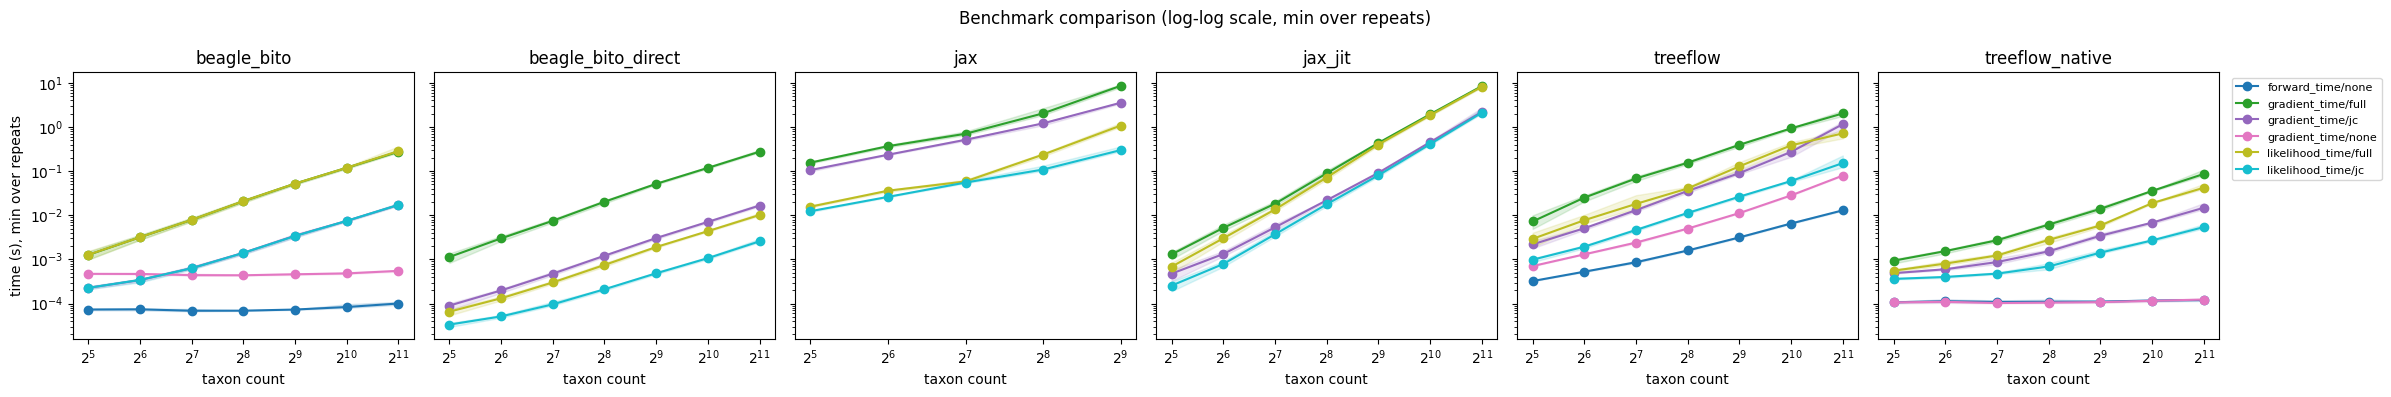

In [7]:
def comparison_plot(df, stat="min", log_scales=True, title=""):
    """Per-method panels of time vs. taxon count, coloured by computation/model
    -- a matplotlib equivalent of the old pipeline's R `comparisonPlot`. Uses a
    single `stat` ("mean" or "min") so each line reflects one timing summary;
    see the dedicated mean-vs-min comparison below for how the two differ."""
    df = df[df["stat"] == stat]
    methods = sorted(df["method"].unique())
    fig, axes = plt.subplots(1, len(methods), figsize=(4 * len(methods), 4), sharey=log_scales)
    if len(methods) == 1:
        axes = [axes]
    groups = [key for key, _ in df.groupby(["computation", "model"])]
    colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))
    for ax, method in zip(axes, methods):
        method_df = df[df["method"] == method]
        for (computation, model), color in zip(groups, colors):
            group_df = method_df[(method_df["computation"] == computation) & (method_df["model"] == model)]
            summary = group_df.groupby("taxon_count")["time"].agg(["mean", "min", "max"])
            if summary.empty:
                continue
            ax.plot(summary.index, summary["mean"], "o-", color=color, label=f"{computation}/{model}")
            ax.fill_between(summary.index, summary["min"], summary["max"], color=color, alpha=0.15)
        if log_scales:
            ax.set_xscale("log", base=2)
            ax.set_yscale("log")
        ax.set_title(method)
        ax.set_xlabel("taxon count")
    axes[0].set_ylabel(f"time (s), {stat} over repeats")
    axes[-1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
    fig.suptitle(title)
    fig.tight_layout()
    return fig


fig = comparison_plot(plot_data, stat="min", log_scales=True, title="Benchmark comparison (log-log scale, min over repeats)")
fig.savefig(data_dir / "log-scale-plot.png", dpi=150, bbox_inches="tight")
plt.show()

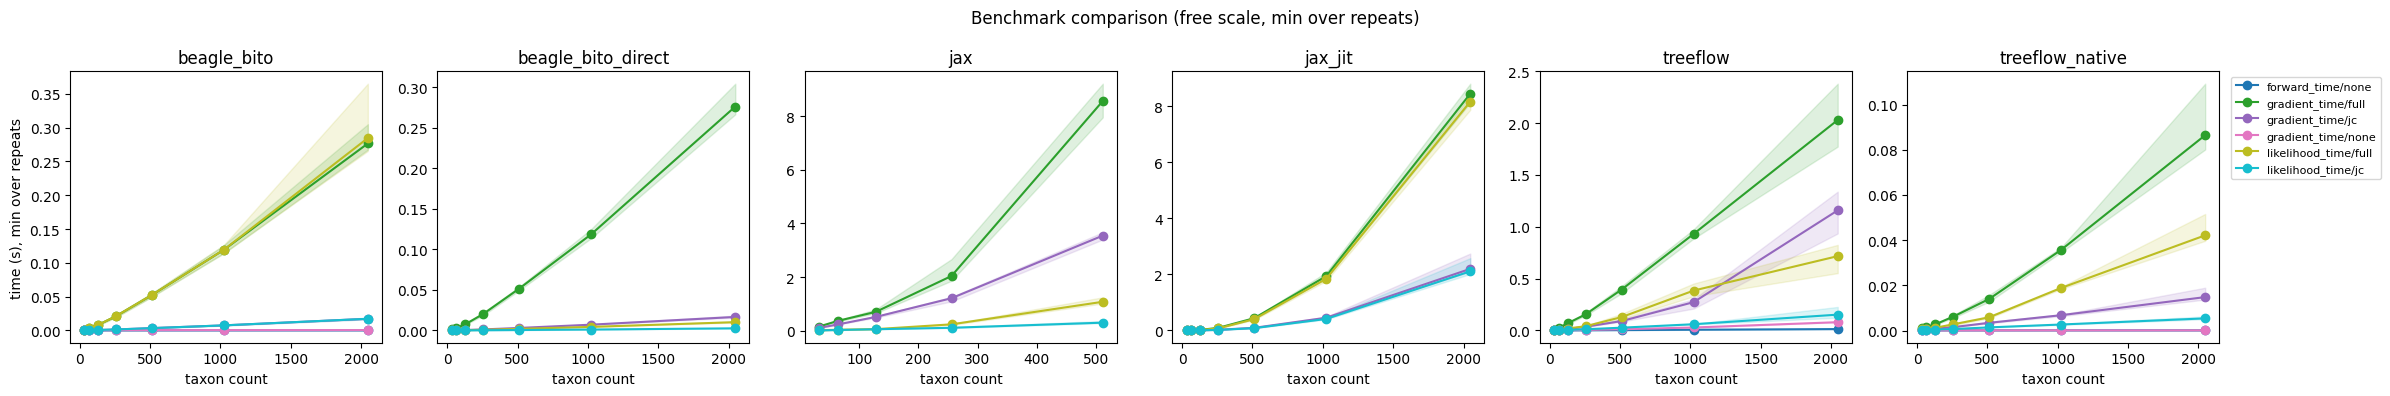

In [8]:
fig = comparison_plot(plot_data, stat="min", log_scales=False, title="Benchmark comparison (free scale, min over repeats)")
fig.savefig(data_dir / "free-scale-plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Speedup relative to the plain TensorFlow-graph implementation

At the largest simulated taxon count, how much faster is each method than `treeflow` (no native ops)?

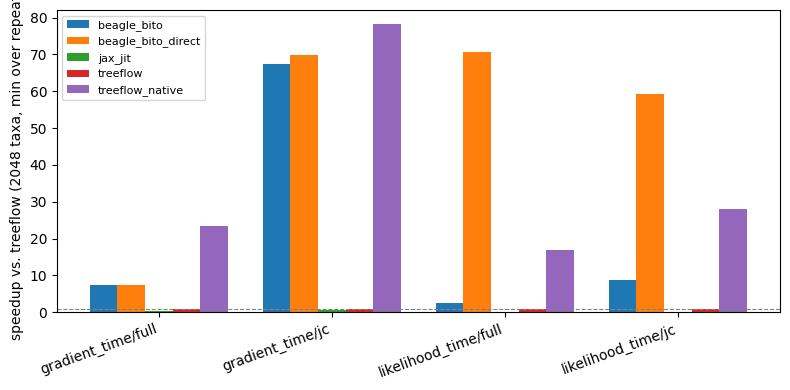

In [9]:
max_taxa = max(TAXON_COUNTS)
baseline = "treeflow"
subset = plot_data[
    (plot_data["taxon_count"] == max_taxa)
    & (plot_data["task"] == "likelihood")
    & (plot_data["stat"] == "min")
]
means = subset.groupby(["method", "computation", "model"])["time"].mean().unstack(["computation", "model"])
baseline_means = means.loc[baseline]
speedup = baseline_means / means

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(speedup.columns))
width = 0.8 / len(speedup.index)
for i, method in enumerate(speedup.index):
    ax.bar(x + i * width, speedup.loc[method].values, width=width, label=method)
ax.axhline(1.0, color="grey", lw=0.8, ls="--")
ax.set_xticks(x + width * (len(speedup.index) - 1) / 2)
ax.set_xticklabels(["/".join(c) for c in speedup.columns], rotation=20, ha="right")
ax.set_ylabel(f"speedup vs. {baseline} ({max_taxa} taxa, min over repeats)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(data_dir / "speedup-plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Mean vs. min across repeats

Each `(taxon_count, method, computation)` cell was timed `REPEATS` times on the *same* fixed input. `min` discards positive scheduling/dispatch noise (it can only be an over-estimate of the true per-call cost, never an under-estimate), while `mean` is pulled upward by that noise -- the gap between them is itself a useful diagnostic: a small, stable gap means dispatch overhead is a minor fraction of the call; a large or taxon-count-dependent gap means overhead (not the traversal itself) is driving the measurement, which was exactly the problem with the earlier batch-of-different-inputs timing this replaced.

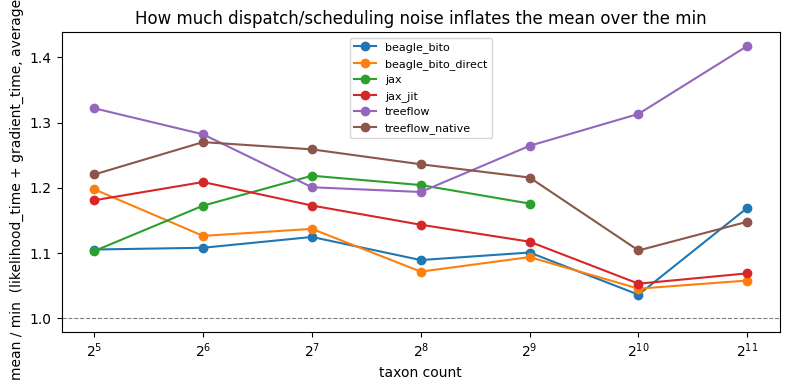

stat,method,computation,model,taxon_count,mean,min,mean_over_min
0,beagle_bito,gradient_time,full,32,0.001367,0.001266,1.080310
1,beagle_bito,gradient_time,full,64,0.003364,0.003182,1.057247
2,beagle_bito,gradient_time,full,128,0.008387,0.007860,1.067093
3,beagle_bito,gradient_time,full,256,0.021800,0.020807,1.047730
4,beagle_bito,gradient_time,full,512,0.055848,0.052189,1.070105
...,...,...,...,...,...,...,...
155,treeflow_native,likelihood_time,jc,128,0.000610,0.000477,1.278272
156,treeflow_native,likelihood_time,jc,256,0.000878,0.000693,1.267568
157,treeflow_native,likelihood_time,jc,512,0.001748,0.001427,1.224262
158,treeflow_native,likelihood_time,jc,1024,0.003096,0.002699,1.147238


In [10]:
likelihood_min_mean = (
    plot_data[plot_data["task"] == "likelihood"]
    .pivot_table(index=["method", "computation", "model", "taxon_count"], columns="stat", values="time")
    .reset_index()
)
likelihood_min_mean["mean_over_min"] = likelihood_min_mean["mean"] / likelihood_min_mean["min"]

fig, ax = plt.subplots(figsize=(8, 4))
for method, group in likelihood_min_mean.groupby("method"):
    by_taxa = group.groupby("taxon_count")["mean_over_min"].mean()
    ax.plot(by_taxa.index, by_taxa.values, "o-", label=method)
ax.axhline(1.0, color="grey", lw=0.8, ls="--")
ax.set_xscale("log", base=2)
ax.set_xlabel("taxon count")
ax.set_ylabel("mean / min  (likelihood_time + gradient_time, averaged)")
ax.set_title("How much dispatch/scheduling noise inflates the mean over the min")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(data_dir / "mean-vs-min-plot.png", dpi=150, bbox_inches="tight")
plt.show()

likelihood_min_mean.sort_values(["method", "computation", "model", "taxon_count"])

### Log-log scaling exponents

Slope close to 1 is linear scaling in taxon count; treeflow's tree traversal is inherently linear, so values near 1 are expected for the likelihood and near/below 1 for the ratio transform.

In [11]:
fit_table.sort_values(["computation", "model", "method"])

,method,computation,model,stat,slope,intercept
0,beagle_bito,forward_time,none,mean,0.099306,-9.844869
1,beagle_bito,forward_time,none,min,0.063742,-9.827591
36,treeflow,forward_time,none,mean,0.887778,-11.144769
37,treeflow,forward_time,none,min,0.896154,-11.286474
48,treeflow_native,forward_time,none,mean,0.039850,-9.127702
49,treeflow_native,forward_time,none,min,0.023028,-9.222475
2,beagle_bito,gradient_time,full,mean,1.306833,-11.114300
3,beagle_bito,gradient_time,full,min,1.304663,-11.165967
12,beagle_bito_direct,gradient_time,full,mean,1.318882,-11.230950
13,beagle_bito_direct,gradient_time,full,min,1.329475,-11.341579
